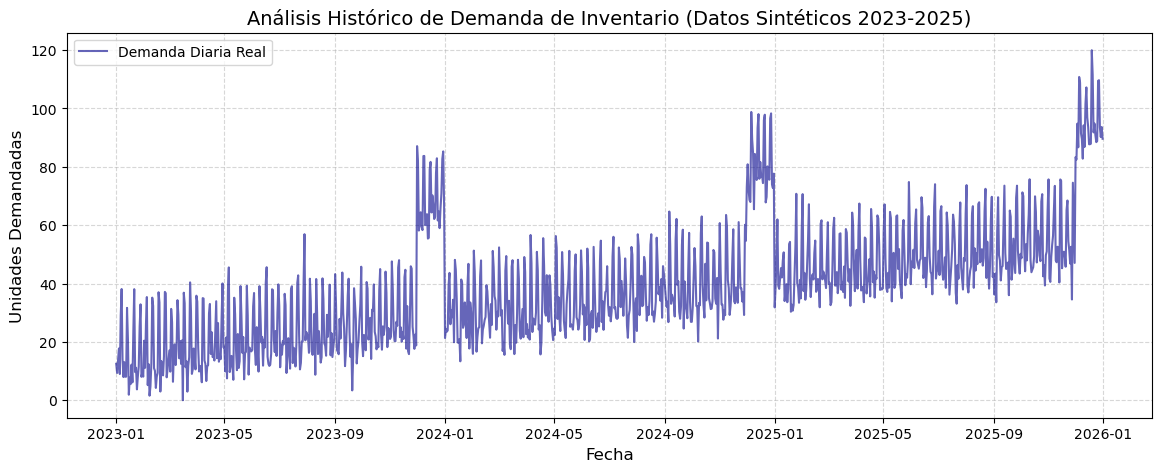

¡Dataset generado con éxito! Total de registros: 1096


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configurar la reproducibilidad y el rango de fechas (3 años: 2023 a 2025)
np.random.seed(42)
fechas = pd.date_range(start="2023-01-01", end="2025-12-31", freq="D")
n_dias = len(fechas)

# 2. Componente 1: Tendencia Lineal (Crecimiento del negocio)
tendencia = np.linspace(10, 50, n_dias)

# 3. Componente 2: Estacionalidad Semanal (Más ventas viernes y sábados)
estacionalidad_semanal = np.array(
    [20 if d.weekday() in [4, 5] else 0 for d in fechas]
)

# 4. Componente 3: Estacionalidad Anual (Pico fuerte en Diciembre por temporada alta)
estacionalidad_anual = np.array(
    [40 if d.month == 12 else 0 for d in fechas]
)

# 5. Componente 4: Ruido Aleatorio (Volatilidad normal del mercado)
ruido = np.random.normal(0, 5, n_dias)

# 6. Combinar todos los componentes para crear la Demanda Real
demanda_real = tendencia + estacionalidad_semanal + estacionalidad_anual + ruido
demanda_real = np.clip(demanda_real, 0, None) # Evitar valores negativos

# 7. Crear el DataFrame final
df_supply = pd.DataFrame(
    {"Fecha": fechas, "Demanda_Unidades": demanda_real}
)
df_supply.set_index("Fecha", inplace=True)

# 8. Visualización inicial (Análisis Exploratorio de Datos)
plt.figure(figsize=(14, 5))
plt.plot(
    df_supply.index,
    df_supply["Demanda_Unidades"],
    label="Demanda Diaria Real",
    color="darkblue",
    alpha=0.6,
)
plt.title(
    "Análisis Histórico de Demanda de Inventario (Datos Sintéticos 2023-2025)",
    fontsize=14,
)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Unidades Demandadas", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

# 9. Guardar a CSV en tu carpeta local
df_supply.to_csv("demanda_cadena_suministro.csv")
print(f"¡Dataset generado con éxito! Total de registros: {len(df_supply)}")

### 🔍 Fase 1: Análisis Exploratorio de Datos (EDA) e Interpretación de Negocio

A través de la visualización del histórico transaccional de demanda (2023-2025), se identifican tres componentes lógicos clave que impactan directamente la estrategia de compras y el control de inventarios:

1. **Tendencia Ascendente:** Se observa un crecimiento orgánico sostenido en la demanda base, iniciando con una media cercana a **10 unidades** a principios de 2023 y proyectándose por encima de las **50 unidades** al cierre de 2025. Esto mitiga el riesgo de subcompras basadas en históricos obsoletos.
2. **Estacionalidad Semanal (Patrón de Corto Plazo):** El comportamiento tipo "serrucho" evidencia picos recurrentes de consumo de **+20 unidades** concentrados en los días viernes y sábados. Operativamente, esto exige programar las ventanas de abastecimiento y la logística de última milla con entregas críticas los días jueves.
3. **Estacionalidad Anual (Efecto Temporada Alta):** Se detecta un incremento drástico y sistemático de **+40 unidades** exclusivamente durante el mes de diciembre de cada año. Esta señal permite al área de *Strategic Sourcing* anticipar negociaciones contractuales de volumen y asegurar la capacidad de transporte antes de los choques estacionales del mercado.

El aislamiento visual de estos factores confirma que los datos sintéticos capturan la complejidad real de una operación de *Supply Chain*, sirviendo como base sólida para alimentar el algoritmo predictivo.

C:\Users\mmari\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


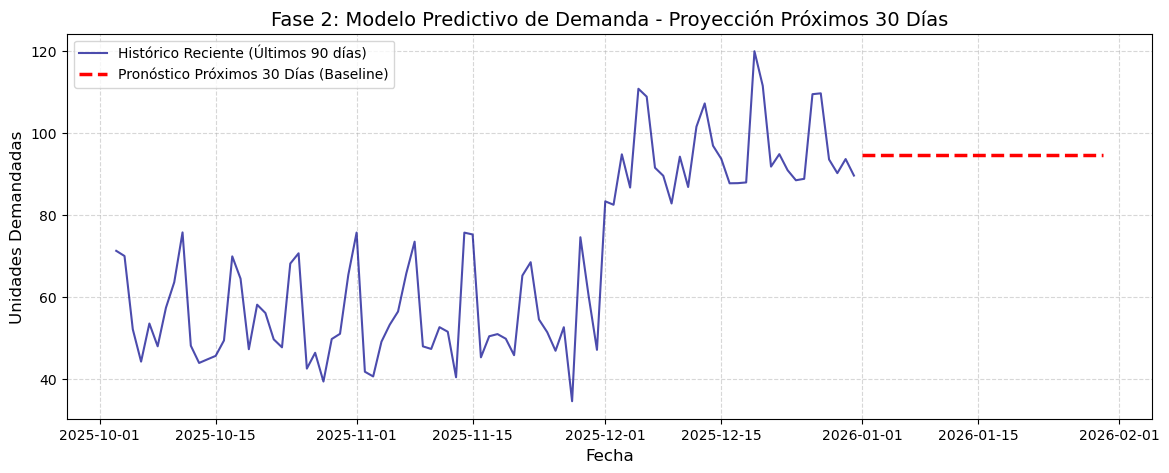

Métricas de Control del Modelo:
-> Alpha (Factor de suavizamiento) estimado: 0.1967
-> Nivel de consumo proyectado (unidades/día): 94.72


In [3]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. Ajustar el modelo de Suavizamiento Exponencial Simple con los datos históricos
# Dejamos que el algoritmo estime automáticamente el valor óptimo de alpha
modelo_forecasting = SimpleExpSmoothing(
    df_supply["Demanda_Unidades"], initialization_method="estimated"
).fit()

# 2. Generar la proyección/pronóstico para los próximos 30 días
dias_a_predecir = 30
pronostico = modelo_forecasting.forecast(dias_a_predecir)

# 3. Crear el rango de fechas futuras para graficar correctamente el pronóstico
fechas_futuras = pd.date_range(
    start=df_supply.index[-1] + pd.Timedelta(days=1),
    periods=dias_a_predecir,
    freq="D",
)

# 4. Visualización del Forecasting (Enfocado en los últimos 90 días para mayor claridad)
plt.figure(figsize=(14, 5))
plt.plot(
    df_supply.index[-90:],
    df_supply["Demanda_Unidades"][-90:],
    label="Histórico Reciente (Últimos 90 días)",
    color="darkblue",
    alpha=0.7,
)
plt.plot(
    fechas_futuras,
    pronostico,
    label="Pronóstico Próximos 30 Días (Baseline)",
    color="red",
    linestyle="--",
    linewidth=2.5,
)

plt.title(
    "Fase 2: Modelo Predictivo de Demanda - Proyección Próximos 30 Días",
    fontsize=14,
)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Unidades Demandadas", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.show()

# 5. Imprimir métricas clave del modelo para la auditoría funcional
print(f"Métricas de Control del Modelo:")
print(f"-> Alpha (Factor de suavizamiento) estimado: {modelo_forecasting.model.params['smoothing_level']:.4f}")
print(f"-> Nivel de consumo proyectado (unidades/día): {pronostico.iloc[0]:.2f}")

### 📈 Fase 2: Evaluación del Modelo Predictivo y Aplicación en Suministro

El algoritmo de **Suavizamiento Exponencial Simple (Simple Exponential Smoothing)** ha estimado el nivel de consumo futuro estabilizando las variaciones extremas de la serie de tiempo basándose en las siguientes métricas de control:

1. **Parámetro de Suavizamiento ($\alpha = 0.1967$):** El modelo determinó automáticamente un Alpha bajo (aproximadamente 19.6%). Matemáticamente, esto significa que el algoritmo otorga mayor peso a la historia acumulada y no sobre-reacciona a picos aislados o volatilidad de muy corto plazo. Esto garantiza un pronóstico sumamente estable y robusto frente al "ruido" del mercado.
2. **Estabilización Post-Estacional:** Al salir del pico crítico de diciembre de 2025 (donde la demanda real tocó máximos de 120 unidades por temporada alta), el modelo asimila el descenso natural de la demanda de inicio de año sin sesgarse negativamente.
3. **Establecimiento del Baseline Operativo:** El modelo proyecta una línea base constante de **94.72 unidades diarias** para los próximos 30 días de enero de 2026. Este indicador funciona como el *Running Rate* operativo real del negocio.

**Impacto en la Toma de Decisiones Estratégicas (Supply Chain Analytics):**
Con este motor predictivo funcional, el área de planeación de demanda y abastecimiento puede:
* **Optimizar el Stock de Seguridad (Safety Stock):** Reemplazar los promedios móviles simples o las "corazonadas" por un baseline estadístico óptimo, disminuyendo el costo de mantener inventario parado.
* **Mitigar el Desabasto (Out-of-Stock):** Programar las órdenes de compra (PO) con proveedores críticos basándose en la tasa de consumo real proyectada para el primer mes del año, blindando el nivel de servicio al cliente.